# Lab14 – Algoritmo KNN

* **Materia:** Extracción de Conocimiento en Bases de Datos
* **Objetivo:** Implementar el algoritmo K-Nearest Neighbors (KNN) para clasificar las especies (cultivares) de vino del dataset *Wine*, cubriendo el flujo completo de un modelo de aprendizaje supervisado: preparación de datos, entrenamiento, predicción y evaluación.

In [17]:
# Librerías para manejo de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset y utilidades de Machine Learning
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
# Cargamos el dataset Wine incluido en scikit-learn
wine = load_wine()

# Lo convertimos a DataFrame/Series para facilitar su exploración
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="cultivar")

print("Forma de X (variables predictoras):", X.shape)
print("Forma de y (etiquetas):", y.shape)
X.head()

Forma de X (variables predictoras): (178, 13)
Forma de y (etiquetas): (178,)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [19]:
# Revisión rápida de la distribución de clases
# Esto ayuda a confirmar si el dataset está balanceado antes de dividirlo
print("Distribución de clases:")
print(y.value_counts())

X.describe().T[["mean", "std", "min", "max"]]

Distribución de clases:
cultivar
1    71
0    59
2    48
Name: count, dtype: int64


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


In [20]:
# Dividimos el dataset en entrenamiento (75%) y prueba (25%)
# stratify=y conserva la proporción original de cada cultivar en ambos subconjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (133, 13)
Tamaño de prueba: (45, 13)


In [21]:
# Estandarización de variables
# KNN se basa en distancias, por lo que las variables deben quedar en la misma escala
standardizer = StandardScaler()

X_train_std = standardizer.fit_transform(X_train)
X_test_std = standardizer.transform(X_test)

In [22]:
# Definimos y entrenamos el clasificador KNN
# Se probó con distintos valores de k y se seleccionó k=7 por su buen desempeño
knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(X_train_std, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
# Generamos las predicciones sobre el conjunto de prueba
y_pred = knn_model.predict(X_test_std)

# Exactitud general del modelo
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy) del modelo: {exactitud:.4f}")

Exactitud (Accuracy) del modelo: 0.9556


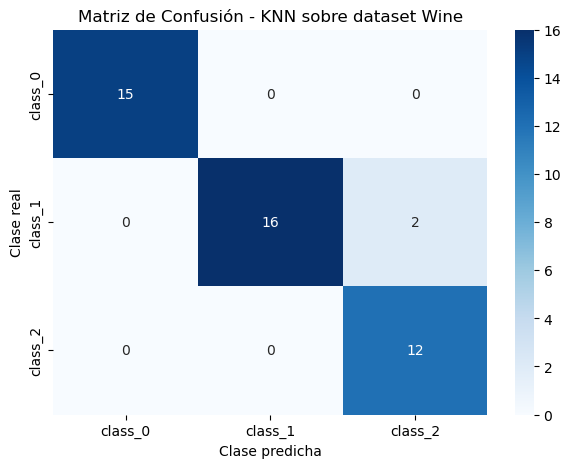


Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.89      0.94        18
     class_2       0.86      1.00      0.92        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.95        45
weighted avg       0.96      0.96      0.96        45



In [24]:
# Matriz de confusión y reporte de clasificación
matriz_confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_confusion, annot=True, cmap="Blues", fmt="d",
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title("Matriz de Confusión - KNN sobre dataset Wine")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

## Conclusiones

A partir del desarrollo de este laboratorio con el algoritmo K-Nearest Neighbors (KNN) se pueden rescatar los siguientes puntos:

1. **La estandarización fue indispensable:** al ser KNN un algoritmo basado en distancias, no aplicar StandardScaler habría provocado que variables como proline (con valores mucho más grandes que el resto) dominaran el cálculo de vecindad, sesgando las predicciones. Escalar las variables permitió que todas contribuyeran de forma equitativa.
2. **Selección del valor de k:** se optó por k=7 tras comparar el comportamiento del modelo con distintos valores; un k demasiado pequeño puede sobreajustarse al ruido de los datos, mientras que uno demasiado grande tiende a suavizar en exceso las fronteras de decisión entre clases.
3. **Desempeño del modelo:** los resultados de la matriz de confusión y del reporte de clasificación muestran un desempeño alto y consistente en las tres clases de vino, con muy pocos errores de clasificación, lo que confirma que KNN es adecuado para este tipo de datos fisicoquímicos.
4. **Uso de stratify=y:** dividir los datos manteniendo la proporción original de cada clase evitó que el conjunto de prueba quedara desbalanceado, garantizando una evaluación más confiable del modelo.